## Face-to-BMI

## 1.Pacakges

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import random
from PIL import Image
from collections import Counter
import cv2

## 2. Read and get data label data

In [2]:
folder_path = Path('your/folder/path')
if folder_path.is_dir():
    print("The folder exists.")

In [3]:
# Get working path
working_path = Path.cwd()
print(working_path)
# Verify that the Data folder exists
data_path = working_path / 'Data'
if data_path.is_dir():
    print("The data folder exists:",data_path )
else:
    print('Please download the data Face-to-BMI: Using Computer Vision to Infer Body Mass Index on Social Media Paper')

/Users/mattl/Documents/U Chicago/Q3/ML_2/Final Project/BMI
The data folder exists: /Users/mattl/Documents/U Chicago/Q3/ML_2/Final Project/BMI/Data


In [4]:
# Read label data
df_label = pd.read_csv(data_path /'data.csv')
print('Shape:', df_label.shape)
df_label.info()

Shape: (4206, 5)
<class 'pandas.DataFrame'>
RangeIndex: 4206 entries, 0 to 4205
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   4206 non-null   int64  
 1   bmi          4206 non-null   float64
 2   gender       4206 non-null   str    
 3   is_training  4206 non-null   int64  
 4   name         4206 non-null   str    
dtypes: float64(1), int64(2), str(2)
memory usage: 232.5 KB


We don't have any missing values in the label dataset

In [5]:
# Rename index column
df_label.rename(columns={'Unnamed: 0': 'image_index'}, inplace=True)

In [6]:
# Main images path
images_path = data_path / 'Images'
# Get the all the files names files 
files = [f for f in Path(images_path).iterdir() if f.is_file()]

# Eliminate the rows that doesn't have a image
total_rows = df_label.shape[0]
paths_images = []
drop_index = []
for i in range(0, total_rows):
    # Validate that the image exists
    actual_image_path = images_path / ('img_'+ str(i) + '.bmp')
    actual_image_path = str(actual_image_path)
    try:
        with Image.open(actual_image_path) as img:
            img.verify()  # Checks see if the image exists
            paths_images.append(actual_image_path)
    except Exception as e:
        drop_index.append(i)
       
df_label = df_label.drop(drop_index, axis=0).reset_index(drop=True)
print('Number of rows drop:', len(drop_index))
print('Number of images in Data folder: ',len(files) )
print('Number of rows in the dataframe: ',df_label.shape[0] )
# Add paths to the dataframe
df_label['images_path'] = paths_images
 

Number of rows drop: 244
Number of images in Data folder:  3963
Number of rows in the dataframe:  3962


In [7]:
display(df_label.head(10))

,image_index,bmi,gender,is_training,name,images_path
0,0,34.207396,Male,1,img_0.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...
1,1,26.453720,Male,1,img_1.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...
2,2,34.967561,Female,1,img_2.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...
3,3,22.044766,Female,1,img_3.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...
4,6,25.845588,Female,1,img_6.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...
5,7,21.740701,Female,1,img_7.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...
6,8,30.615858,Female,1,img_8.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...
7,9,26.788876,Female,1,img_9.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...
8,10,38.732782,Male,1,img_10.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...
9,11,30.824839,Male,1,img_11.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...


In [8]:
# Create additional BMI category describe in the paper
# Define the bin edges and labels
bins = [0, 18.5, 25, 30, 35, 40, 10000]
labels = ['under-weight', 'normal', 'overweight', 'moderately obese', 'severely obese', 'very severely obese']
# Create the new category column
df_label['BMI_category'] = pd.cut(df_label['bmi'], bins=bins, labels=labels)


# The cvs doesn't have a column to specific the before and after, but looking at the records we can see that images are organize by index in that raltionship (before/after)
df_label['index_pair'] =  df_label['image_index'] // 2
# Create flag before and after
df_label['flag_before_after'] = np.where( df_label['index_pair'] != df_label['index_pair'].shift(1), 'before','after')

In [9]:
# Check distribution of gender
display(df_label.head(10))

,image_index,bmi,gender,is_training,name,images_path,BMI_category,index_pair,flag_before_after
0,0,34.207396,Male,1,img_0.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...,moderately obese,0,before
1,1,26.453720,Male,1,img_1.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...,overweight,0,after
2,2,34.967561,Female,1,img_2.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...,moderately obese,1,before
3,3,22.044766,Female,1,img_3.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...,normal,1,after
4,6,25.845588,Female,1,img_6.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...,overweight,3,before
5,7,21.740701,Female,1,img_7.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...,normal,3,after
6,8,30.615858,Female,1,img_8.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...,moderately obese,4,before
7,9,26.788876,Female,1,img_9.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...,overweight,4,after
8,10,38.732782,Male,1,img_10.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...,severely obese,5,before
9,11,30.824839,Male,1,img_11.bmp,/Users/mattl/Documents/U Chicago/Q3/ML_2/Final...,moderately obese,5,after


## 3. Create plots

**Numerical variables**

count    3962.000000
mean       32.674278
std         8.272575
min        17.716216
25%        26.443866
50%        31.166739
75%        37.492724
max        85.987061
Name: bmi, dtype: float64

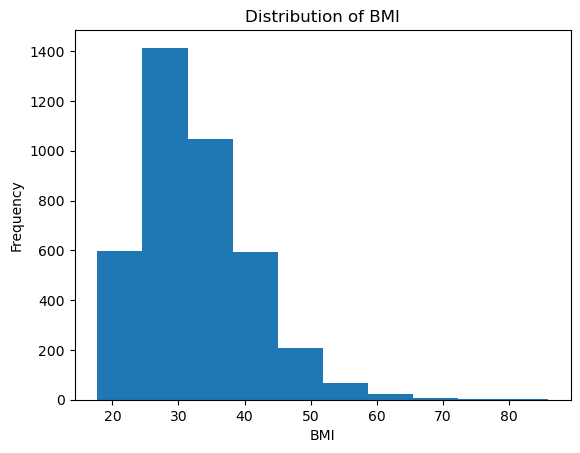

In [10]:
display(df_label['bmi'].describe())
plt.hist(df_label['bmi'])
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

The average BMI is 32.80 with 8.2 points of standard deviation, the highest concentration is around 25-30.

**Categorical variables**

Feature: gender


,gender,avg_bmi,count_records
0,Female,32.77,1608
1,Male,32.61,2354


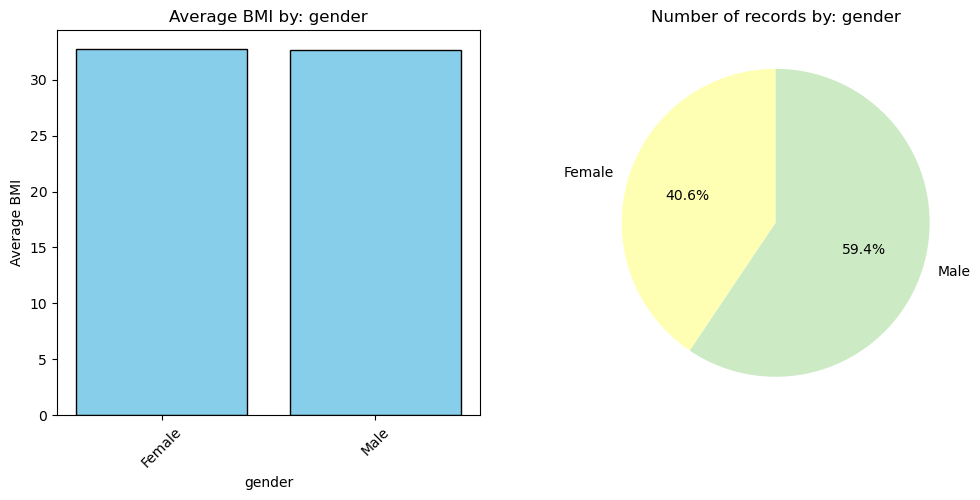

Feature: BMI_category


,BMI_category,avg_bmi,count_records
5,very severely obese,46.29,695
4,severely obese,37.40,625
3,moderately obese,32.40,885
2,overweight,27.46,1087
1,normal,23.02,663
0,under-weight,18.04,7


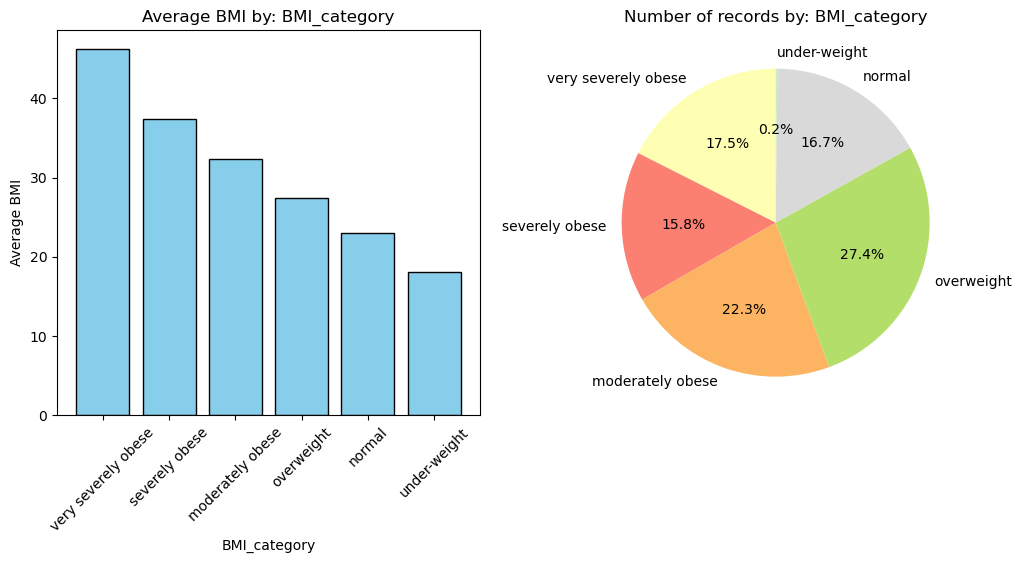

In [11]:
# Check categorical features relationship with the target variable
categorical_features = ['gender', 'BMI_category']

for feature in categorical_features:
    print("Feature:", feature)
    # Create summary table for the feature and the target variable
    df_aux = df_label.groupby(feature)['bmi'].agg(['mean', 'count']).reset_index()
    df_aux.rename(columns={'mean': 'avg_bmi','count': 'count_records'}, inplace=True)
    df_aux['avg_bmi'] = round(df_aux['avg_bmi'],2)
    df_aux = df_aux.sort_values(by='avg_bmi', ascending=False)
    display(df_aux)
    # Show graph
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Graph 1: Barplot graph: Average BMI 
    ax1.bar(df_aux[feature], df_aux['avg_bmi'], color='skyblue', edgecolor='black')
    ax1.set_title('Average BMI by: ' + feature)
    ax1.set_xlabel(feature)
    ax1.set_ylabel('Average BMI')
    ax1.tick_params(axis='x', labelrotation=45)

    # Graph 2: Barplot graph: Average BMI 
    cmap = plt.get_cmap('Set3')
    palette_colors = cmap(np.linspace(0.1, 0.9, df_aux[feature].nunique()))
    ax2.pie(df_aux['count_records'], labels=df_aux[feature],colors= palette_colors, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Number of records by: ' + feature )

    plt.show()

* **Gender**: The gender records distribution is the same as in the paper, the dataset contains a slightly higher concentration of males with 58% (2438 observations) in contrast with females, which is 42% (1768 observations), but the average BMI between genders is very similar, around 32 points.
* **BMI Category** The dataset contains unbalanced categories/classes, which is something we need to consider when evaluating the model performance. The overweight/moderately obese represents aprox 50% of the records. The classes normal, severely obese, and very severely obese have a similar frequency of records between 16% to 18% ot the total images. In addition, the under-weight only have 7 records, which is less 1% of the observations, it is a class that is going to be challenging to model.

**Note**: We got the same distribution of the BMI_category as displayed in the paper.

**Difference between train and test paritions**

In [12]:
df_aux = df_label[df_label['is_training']==1]
print('train')
display(df_aux[['bmi']].describe())
display(df_aux[['gender']].value_counts(normalize=True))

df_aux = df_label[df_label['is_training']==0]
print('test')
display(df_aux[['bmi']].describe())
display(df_aux[['gender']].value_counts(normalize=True))

train


,bmi
count,3210.000000
mean,32.434370
std,8.017202
min,17.716216
25%,26.317568
50%,30.996473
75%,37.118916
max,81.211930


gender
Male      0.600312
Female    0.399688
Name: proportion, dtype: float64

test


,bmi
count,752.000000
mean,33.698354
std,9.219863
min,18.651020
25%,26.872880
50%,31.947427
75%,38.867300
max,85.987061


gender
Male      0.567819
Female    0.432181
Name: proportion, dtype: float64

The distribution between the train and test used by the author in the paper is very similar, the test has a slightly higher average BMI compared to the train, but the quantiles of the BMI are very similar between the two datasets, which will not be an issue in the modeling step. In addition, there is more concentration of males in the train dataset with 58%, in contrast with the test 54%, it is something we need to consider in the model train process.

## 4. Images exploration (before/after)

In [13]:
# Check BMI of before and after
display('Before:')
df_aux = df_label[df_label['flag_before_after']=='before']
display(df_aux[['bmi']].describe())
display('After:')
df_aux = df_label[df_label['flag_before_after']=='after']
display(df_aux[['bmi']].describe())

'Before:'

,bmi
count,2003.000000
mean,37.016941
std,8.132383
min,19.770270
25%,31.166739
50%,36.176223
75%,41.314968
max,85.987061


'After:'

,bmi
count,1959.000000
mean,28.234078
std,5.639537
min,17.716216
25%,24.391892
50%,26.995200
75%,31.004461
max,72.084961


In [14]:
df_aux = df_label.copy()
df_aux['before_bmi'] = df_aux['bmi'].shift(1)
# Filter before
df_aux = df_aux[df_aux['flag_before_after'] == 'after']
count_records = np.sum(df_aux['bmi'] > df_aux['before_bmi'])
print('Numers of pairs that have a higher BMI in the after (stage 2) compared to before (stage 1):',count_records )

Numers of pairs that have a higher BMI in the after (stage 2) compared to before (stage 1): 0


Pair index: 797
BMI before: 49.33
BMI after: 33.91


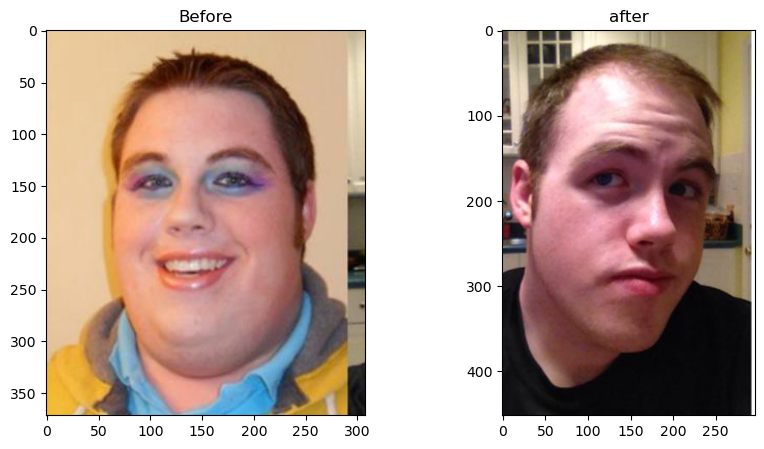

Pair index: 1758
BMI before: 38.37
BMI after: 26.62


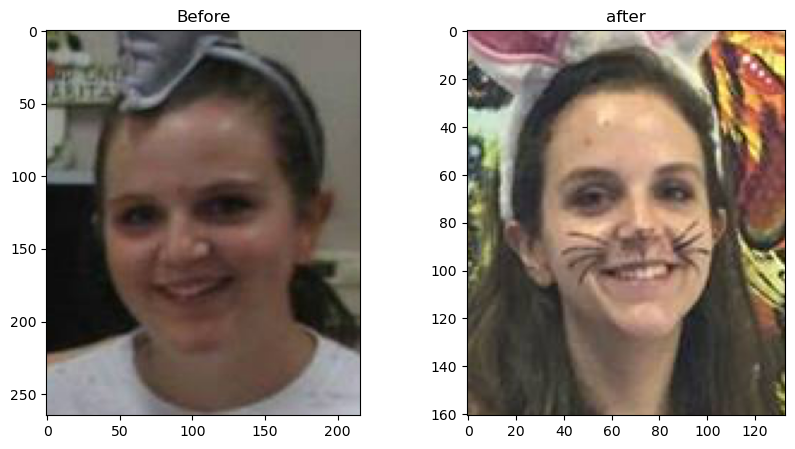

Pair index: 1524
BMI before: 35.42
BMI after: 26.39


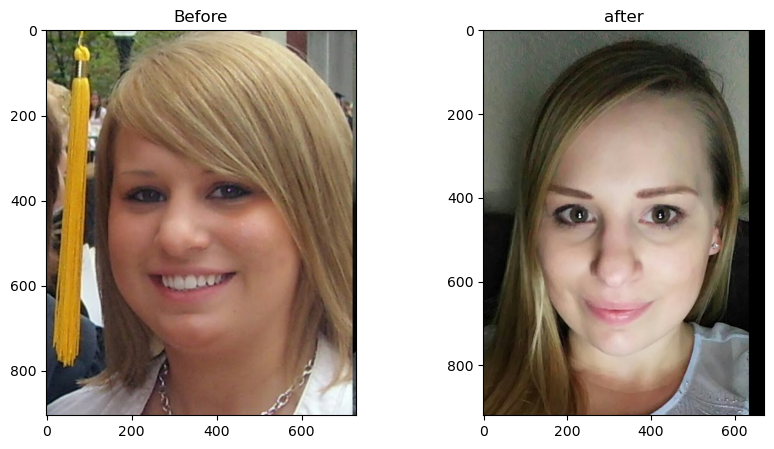

Pair index: 209
BMI before: 47.14
BMI after: 40.87


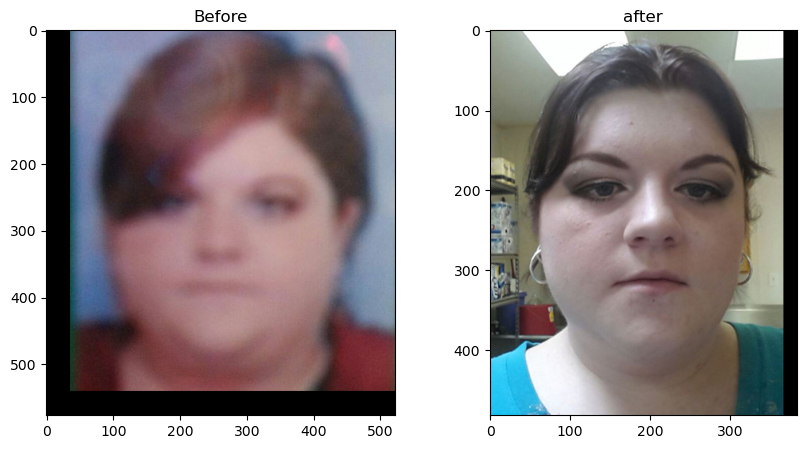

Pair index: 91
BMI before: 31.42
BMI after: 24.31


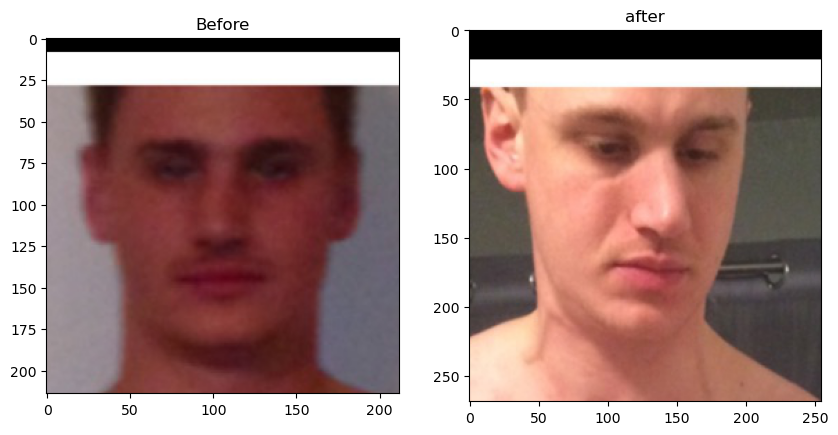

Pair index: 171
BMI before: 29.64
BMI after: 23.71


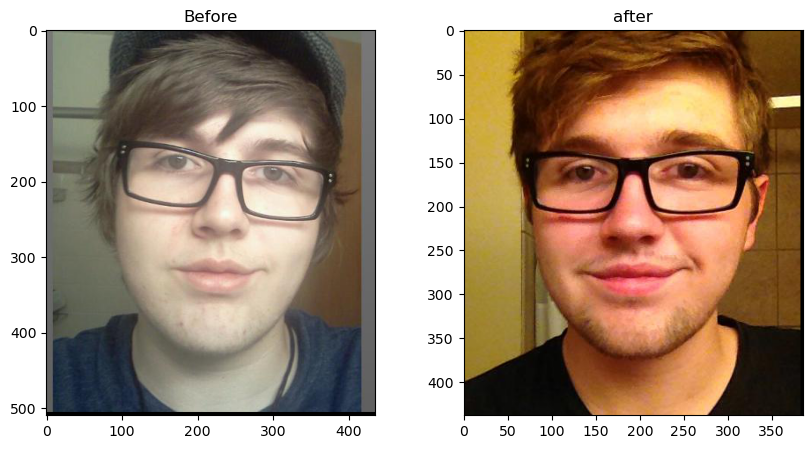

Pair index: 68
BMI before: 42.08
BMI after: 37.8


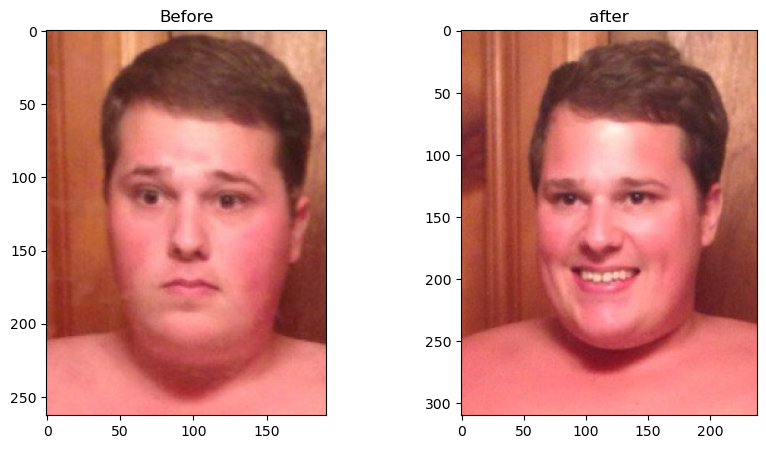

Pair index: 1116
BMI before: 33.08
BMI after: 28.94


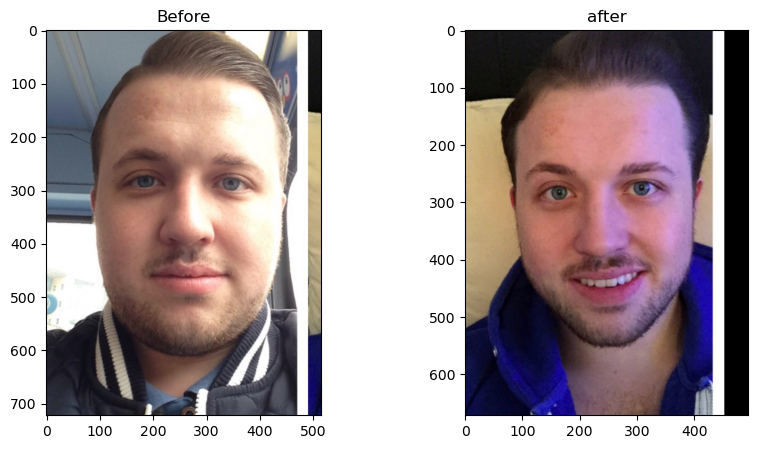

Pair index: 1508
BMI before: 28.71
BMI after: 24.51


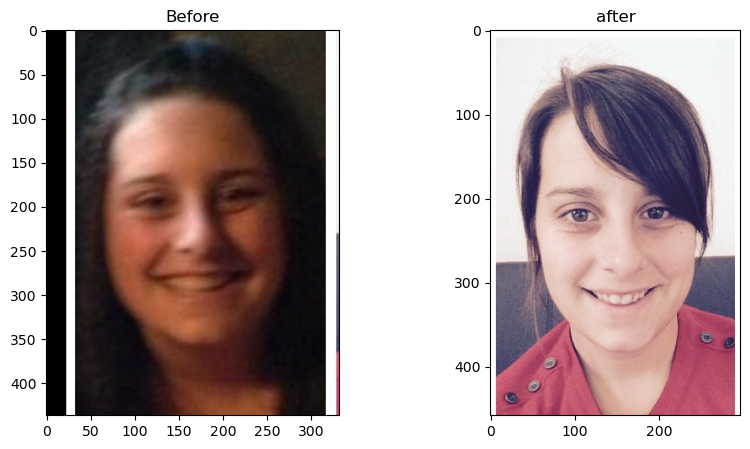

Pair index: 107
BMI before: 28.13
BMI after: 26.45


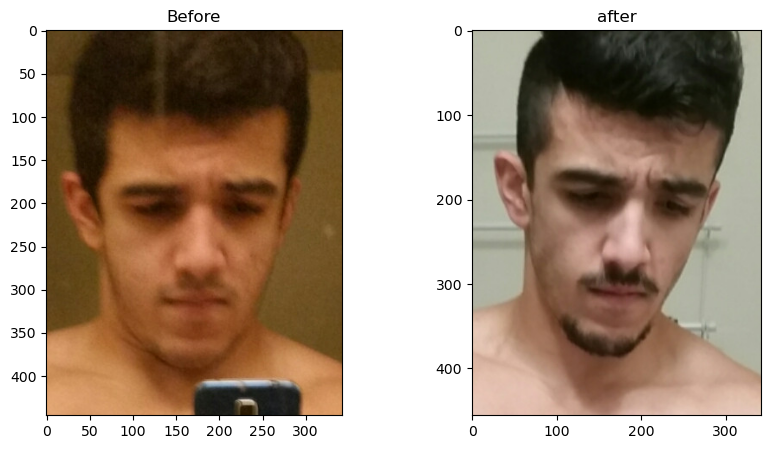

In [15]:
# Generate 10 random cases before/after
random.seed(97)
select_index = random.sample(range(1, 2102), 10)


for pair_index in select_index:

    # get images path before/after
    print('Pair index:', pair_index)
    df_aux = df_label[df_label['index_pair'] == pair_index]
    df_aux.reset_index(drop=True, inplace=True)
    path_before = str(df_aux.loc[0, 'images_path'])
    path_after = df_aux.loc[1, 'images_path']
    print('BMI before:', round(df_aux.loc[0, 'bmi'],2))
    print('BMI after:', round(df_aux.loc[1, 'bmi'],2))

    # Show images
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    img_before = Image.open(path_before)
    ax1.imshow(img_before)
    ax1.set_title('Before')

    img_after = Image.open(path_after)
    ax2.imshow(img_after)
    ax2.set_title('after')
    plt.show()

The before images have a higher average BMI than the after images. The people in the dataset are in better physical condition in the after images. In other words, in any after image record in the dataset, the BMI value is higher than in the before stage.

## 5. Analyze Image Dimensions & Consistency

In [16]:
sizes, modes, aspect_ratios = [], [], []

for img_path in paths_images:
    with Image.open(img_path) as img:
        sizes.append(img.size)           # (width, height)
        modes.append(img.mode)           # RGB, RGBA, L, etc.
        aspect_ratios.append(img.width / img.height)

sizes = np.array(sizes)
print(f"Width  — min: {sizes[:,0].min()}, max: {sizes[:,0].max()}, mean: {sizes[:,0].mean():.0f}")
print(f"Height — min: {sizes[:,1].min()}, max: {sizes[:,1].max()}, mean: {sizes[:,1].mean():.0f}")
print(f"Color modes: {Counter(modes)}")
print(f"Aspect ratios — min: {min(aspect_ratios):.2f}, max: {max(aspect_ratios):.2f}")

Width  — min: 41, max: 900, mean: 293
Height — min: 52, max: 1222, mean: 365
Color modes: Counter({'RGB': 3954, 'P': 8})
Aspect ratios — min: 0.50, max: 1.29


* The width and height are very different depending on the image instance, it is necessary to standardize the size when training the model. 
* Most of the images are RGB, only 8 instances are P. It is necessary to change a few instances to RGB.
* The aspect ratio has a lot of variability, between 0.5 and 1.29.

In [17]:
stats = []

for img_path in paths_images:
    # get index
    df_aux = df_label[df_label['images_path'] == img_path]
    image_index = df_aux['image_index'].values[0]
    # Get image
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # calcualte indicators
    brightness = gray.mean()
    contrast   = gray.std()
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()  # Low = blurry
    
    stats.append({
        "image_index": image_index,
        "brightness": brightness,
        "contrast": contrast,
        "blur": blur_score
    })
# Create dataframe 
df_img_stats = pd.DataFrame(stats)

In [18]:
df_img_stats[['brightness',	'contrast',	'blur']].describe()

,brightness,contrast,blur
count,3962.000000,3962.000000,3962.000000
mean,112.606595,55.844493,349.183441
std,26.662958,13.221963,581.976257
min,27.484947,15.592421,2.215660
25%,94.188665,46.825448,55.366224
50%,112.019439,55.696091,168.966515
75%,130.094561,65.149668,420.251000
max,222.493256,95.889165,11300.384784


In [19]:
# Flag problematic images
df_img_stats['flag_brightness'] = np.where(df_img_stats['brightness']<25, 1, 0)
df_img_stats['flag_contrast'] = np.where(df_img_stats['contrast']<25, 1, 0)
df_img_stats['flag_blur'] = np.where(df_img_stats['blur']<30, 1, 0)
display(df_img_stats.head(10))

,image_index,brightness,contrast,blur,flag_brightness,flag_contrast,flag_blur
0,0,130.244422,57.141387,1600.409138,0,0,0
1,1,89.709788,55.665160,334.331712,0,0,0
2,2,109.184836,59.844535,236.784059,0,0,0
3,3,129.599411,43.259079,564.687801,0,0,0
4,6,145.562319,56.387919,308.159601,0,0,0
5,7,127.825680,55.685398,235.638601,0,0,0
6,8,109.398423,66.856374,18.756039,0,0,1
7,9,133.023774,79.710248,68.779779,0,0,0
8,10,118.637313,50.976513,1022.541611,0,0,0
9,11,112.037571,66.190281,562.964395,0,0,0


In [20]:
# Check values count of flags
display(df_img_stats['flag_brightness'].value_counts())
display(df_img_stats['flag_contrast'].value_counts())
display(df_img_stats['flag_blur'].value_counts())

flag_brightness
0    3962
Name: count, dtype: int64

flag_contrast
0    3928
1      34
Name: count, dtype: int64

flag_blur
0    3383
1     579
Name: count, dtype: int64

Three examples of bad contrast images:

Example: 1
Pair index: 120
BMI before: 36.18
BMI after: 28.79


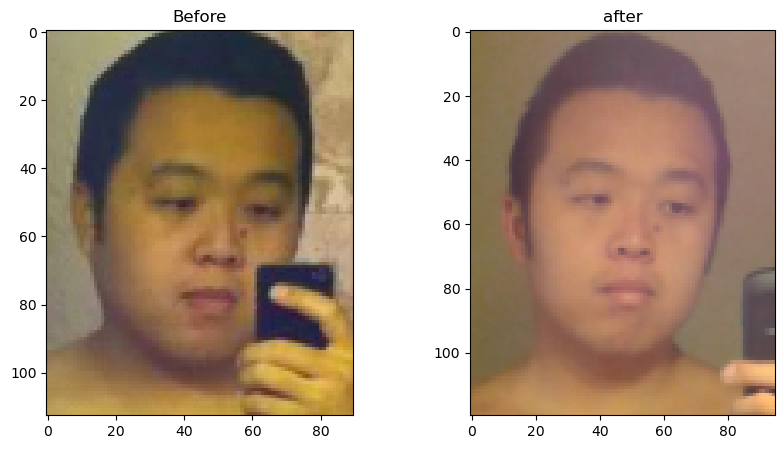

Example: 2
Pair index: 732
BMI before: 33.5
BMI after: 28.48


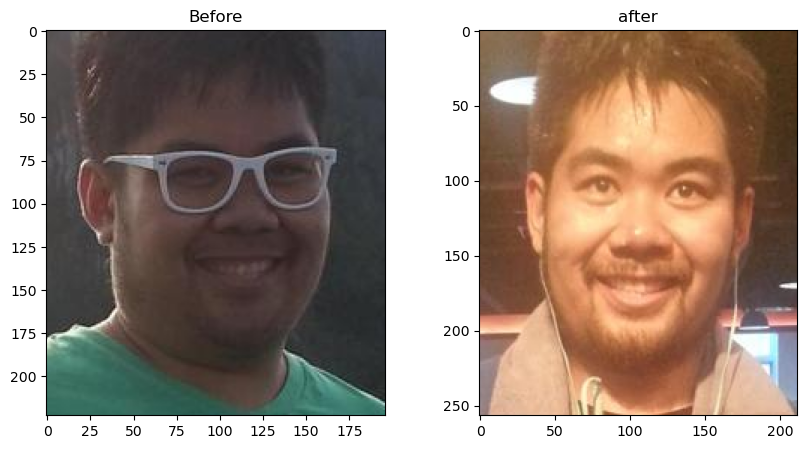

Example: 3
Pair index: 1694
BMI before: 38.34
BMI after: 33.47


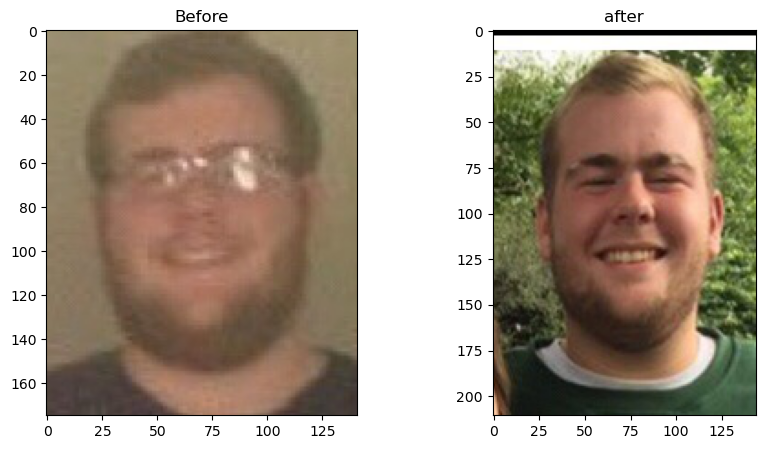

In [21]:
# Generate 10 random cases before/after
random.seed(97)
select_index = random.sample(range(1, 2102), 10)

def sample_images(select_index):
    count = 0
    for pair_index in select_index:
        count+=1
        print('Example:', count)
        # get images path before/after
        print('Pair index:', pair_index)
        df_aux = df_label[df_label['index_pair'] == pair_index]
        df_aux.reset_index(drop=True, inplace=True)
        path_before = str(df_aux.loc[0, 'images_path'])
        path_after = df_aux.loc[1, 'images_path']
        print('BMI before:', round(df_aux.loc[0, 'bmi'],2))
        print('BMI after:', round(df_aux.loc[1, 'bmi'],2))

        # Show images
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

        img_before = Image.open(path_before)
        ax1.imshow(img_before)
        ax1.set_title('Before')

        img_after = Image.open(path_after)
        ax2.imshow(img_after)
        ax2.set_title('after')
        plt.show()

# Three examples flag_contrast using pair_index
print('Three examples of bad contrast images:')
print()
sample_images([120,732, 1694] )

Three examples of bad blur images:

Example: 1
Pair index: 4
BMI before: 30.62
BMI after: 26.79


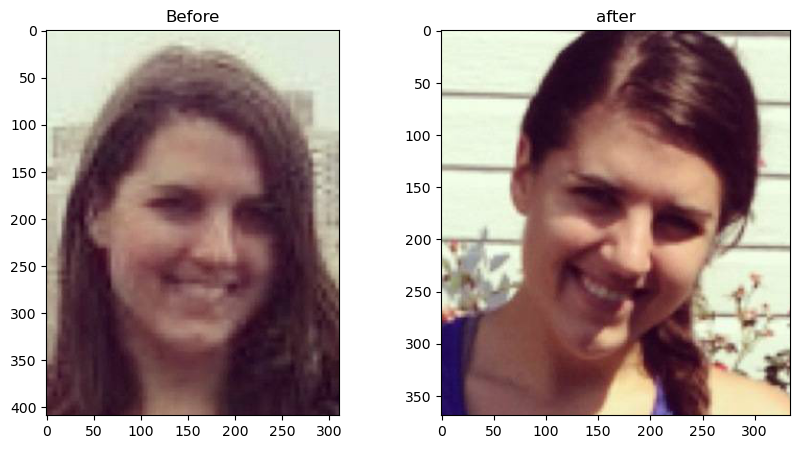

Example: 2
Pair index: 17
BMI before: 29.23
BMI after: 22.14


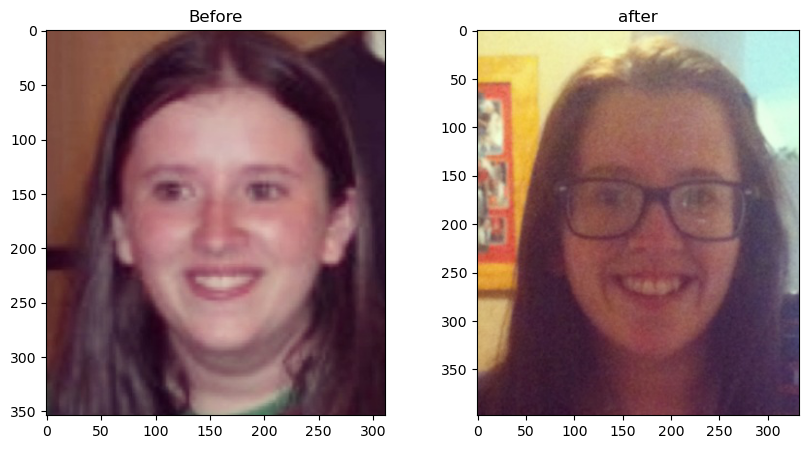

Example: 3
Pair index: 2099
BMI before: 27.12
BMI after: 24.96


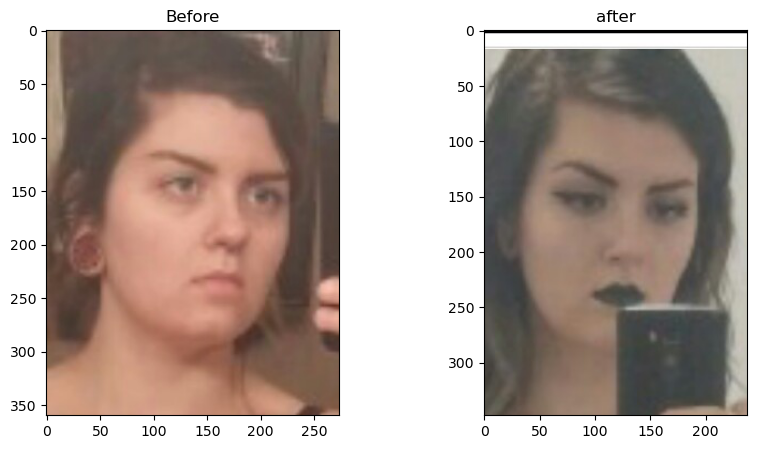

In [22]:
print('Three examples of bad blur images:')
print()
sample_images([4,17, 2099] )


In the modeling part, we can analysis if filtering these images in training we can get better results.

In [23]:
# Join dataframes
inital_rows = df_label.shape[0]
df_label = df_label.merge(df_img_stats, on='image_index', how='inner')
print('Rows before the join {} and rows after the join {}'.format(inital_rows, df_label.shape[0]))
print('Note: It must be the same number of rows')

Rows before the join 3962 and rows after the join 3962
Note: It must be the same number of rows


In [24]:
# Export dataframe as parquet file
df_label.to_parquet(data_path / 'df_EDA_clean.parquet')